In [91]:
# 1. ติดตั้ง Library ที่จำเป็น
!pip install xgboost lightgbm catboost optuna -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import joblib

# นำเข้าเครื่องมือสำหรับสร้าง Pipeline และประเมินผล
from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_absolute_error, r2_score

# นำเข้าโมเดลทั้ง 5 ตัว
from sklearn.ensemble import AdaBoostRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

from sklearn.model_selection import GridSearchCV
import optuna

In [77]:
# โหลดข้อมูล
df = pd.read_csv('SuperStoreOrders - SuperStoreOrders_profit.csv')

# ล้างเครื่องหมายคอมมาในคอลัมน์ sales เพื่อให้คำนวณได้
if df['sales'].dtype == 'object':
    df['sales'] = df['sales'].str.replace(',', '').astype(float)

In [78]:
# --- ส่วนการแสดงข้อมูลเบื้องต้น (EDA) ---

print("=== 1. ข้อมูลทั่วไปของ Dataset ===")
print(df.info())

=== 1. ข้อมูลทั่วไปของ Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  float64
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 

In [82]:
print("=== 2. ค่าทางสถิติของตัวเลข (Numerical Summary) ===")
# ดูค่าเฉลี่ย, ค่าต่ำสุด-สูงสุด ของ Sales, Quantity, Discount และ Profit
print(df[['sales', 'quantity', 'discount', 'profit', 'shipping_cost']].describe())

=== 2. ค่าทางสถิติของตัวเลข (Numerical Summary) ===
              sales      quantity      discount        profit  shipping_cost
count  51290.000000  51290.000000  51290.000000  51290.000000   51290.000000
mean     246.498440      3.476545      0.142908     28.641740      26.375915
std      487.567175      2.278766      0.212280    174.424113      57.296804
min        0.000000      1.000000      0.000000  -6599.978000       0.000000
25%       31.000000      2.000000      0.000000      0.000000       2.610000
50%       85.000000      3.000000      0.000000      9.240000       7.790000
75%      251.000000      5.000000      0.200000     36.810000      24.450000
max    22638.000000     14.000000      0.850000   8399.976000     933.570000


In [81]:
print("=== 3. ตรวจสอบค่าว่าง (Missing Values) ===")
print(df.isnull().sum())

=== 3. ตรวจสอบค่าว่าง (Missing Values) ===
order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64


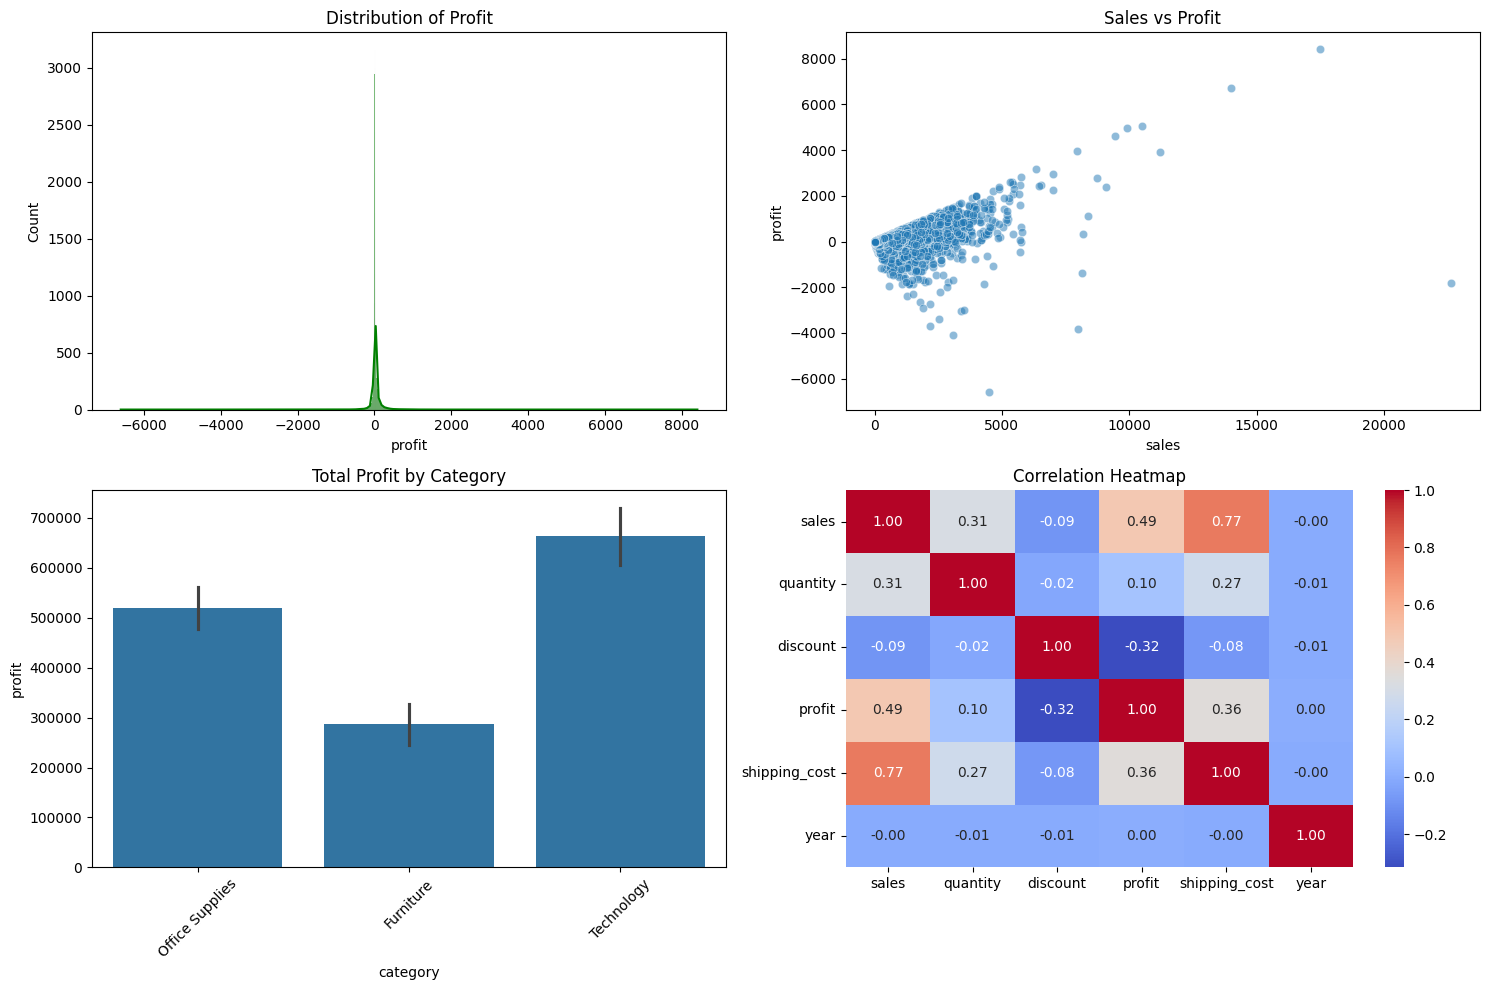

In [104]:
# การแสดงผลด้วยกราฟ (Visualizations)
plt.figure(figsize=(15, 10))

# กราฟที่ 1: การกระจายตัวของ Profit (Target Variable)
plt.subplot(2, 2, 1)
sns.histplot(df['profit'], kde=True, color='green')
plt.title('Distribution of Profit')

# กราฟที่ 2: ความสัมพันธ์ระหว่าง Sales และ Profit
plt.subplot(2, 2, 2)
sns.scatterplot(data=df, x='sales', y='profit', alpha=0.5)
plt.title('Sales vs Profit')

# กราฟที่ 3: กำไรแยกตาม Category
plt.subplot(2, 2, 3)
sns.barplot(data=df, x='category', y='profit', estimator=sum)
plt.title('Total Profit by Category')
plt.xticks(rotation=45)

# กราฟที่ 4: ความสัมพันธ์ (Correlation Matrix)
plt.subplot(2, 2, 4)
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()


In [84]:
print("=== 5. จำนวนข้อมูลแยกตาม Market ===")
print(df['market'].value_counts())

=== 5. จำนวนข้อมูลแยกตาม Market ===
market
APAC      11002
LATAM     10294
EU        10000
US         9994
EMEA       5029
Africa     4587
Canada      384
Name: count, dtype: int64


In [85]:
# แยก Features และ Target
X = df.drop(columns=['profit', 'order_id', 'order_date', 'ship_date', 'customer_name', 'product_id', 'product_name', 'state', 'country'])
y = df['profit']

# แบ่งกลุ่มคอลัมน์
num_cols = ['sales', 'quantity', 'discount', 'shipping_cost', 'year']
cat_cols = ['ship_mode', 'segment', 'market', 'region', 'category', 'sub_category', 'order_priority']

# ออกแบบ Transformer พร้อมเหตุผล
# - ใช้ Median Imputer เพราะทนทานต่อ Outliers
# - ใช้ StandardScaler เพื่อให้ Gradient-based models ทำงานได้เสถียร
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

# แบ่งข้อมูลสำหรับ Train และ Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("สร้าง Pipeline และแบ่งข้อมูลเรียบร้อย!")

สร้าง Pipeline และแบ่งข้อมูลเรียบร้อย!


In [86]:
# รายชื่อโมเดลที่ต้องการทดสอบ
models = {
    "AdaBoost": AdaBoostRegressor(random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42),
    "LightGBM": LGBMRegressor(random_state=42, verbose=-1),
    "CatBoost": CatBoostRegressor(random_state=42, verbose=0)
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
comparison = []

print("กำลังเปรียบเทียบโมเดล...")
for name, model in models.items():
    pipe = Pipeline(steps=[('pre', preprocessor), ('reg', model)])
    # ใช้ Cross-validation เพื่อความแม่นยำ
    scores = cross_val_score(pipe, X_train, y_train, cv=kf, scoring='r2', n_jobs=-1)
    comparison.append({"Model": name, "CV R2 Mean": scores.mean()})

df_compare = pd.DataFrame(comparison).sort_values(by='CV R2 Mean', ascending=False)
print("\n=== ตารางเปรียบเทียบประสิทธิภาพ ===")
print(df_compare)

กำลังเปรียบเทียบโมเดล...

=== ตารางเปรียบเทียบประสิทธิภาพ ===
              Model  CV R2 Mean
1  GradientBoosting    0.699696
4          CatBoost    0.687950
3          LightGBM    0.655551
2           XGBoost    0.626476
0          AdaBoost   -3.186431


In [89]:
# กำหนดค่าพารามิเตอร์ที่จะทดลอง
param_grid = {
    'regressor__n_estimators': [100, 300, 500],
    'regressor__learning_rate': [0.01, 0.05, 0.1],
    'regressor__max_depth': [3, 5]
}

# สร้าง Pipeline พื้นฐาน
base_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(random_state=42))
])

In [92]:
results_tuning = []

# --- 1. Grid Search (แบบละเอียดทุกคู่ผสม) ---
start = time.time()
grid_search = GridSearchCV(base_pipe, param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)
grid_time = time.time() - start
results_tuning.append({'Method': 'Grid Search', 'Best R2': grid_search.best_score_, 'Time (s)': grid_time})

# --- 2. Random Search (แบบสุ่มเลือก 10 รูปแบบ) ---
start = time.time()
random_search = RandomizedSearchCV(base_pipe, param_grid, n_iter=10, cv=3, scoring='r2', n_jobs=-1, random_state=42)
random_search.fit(X_train, y_train)
random_time = time.time() - start
results_tuning.append({'Method': 'Random Search', 'Best R2': random_search.best_score_, 'Time (s)': random_time})

# --- 3. Bayesian Optimization (ด้วย Optuna) ---
def objective(trial):
    # กำหนดช่วงการสุ่มที่ฉลาดขึ้น
    n_estimators = trial.suggest_int('n_estimators', 100, 500)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.1, log=True)
    max_depth = trial.suggest_int('max_depth', 3, 5)

    model = GradientBoostingRegressor(n_estimators=n_estimators, learning_rate=learning_rate, max_depth=max_depth, random_state=42)
    pipe = Pipeline(steps=[('pre', preprocessor), ('reg', model)])
    score = cross_val_score(pipe, X_train, y_train, cv=3, scoring='r2', n_jobs=-1)
    return score.mean()

start = time.time()
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=15) # ลอง 15 รอบ
bayesian_time = time.time() - start
results_tuning.append({'Method': 'Bayesian (Optuna)', 'Best R2': study.best_value, 'Time (s)': bayesian_time})

# --- สรุปผลการเปรียบเทียบ ---
df_tuning = pd.DataFrame(results_tuning)
print("\n=== ตารางเปรียบเทียบวิธีการ Tuning ===")
print(df_tuning)

[I 2026-03-18 21:26:20,221] A new study created in memory with name: no-name-362f5933-7b50-4df0-9640-f6437412e029
[I 2026-03-18 21:27:16,260] Trial 0 finished with value: 0.7112247740368143 and parameters: {'n_estimators': 290, 'learning_rate': 0.05124888587581832, 'max_depth': 5}. Best is trial 0 with value: 0.7112247740368143.
[I 2026-03-18 21:28:05,619] Trial 1 finished with value: 0.7205277544392867 and parameters: {'n_estimators': 349, 'learning_rate': 0.0545228702124772, 'max_depth': 4}. Best is trial 1 with value: 0.7205277544392867.
[I 2026-03-18 21:28:30,469] Trial 2 finished with value: 0.6738944496389405 and parameters: {'n_estimators': 236, 'learning_rate': 0.01537846471453841, 'max_depth': 3}. Best is trial 1 with value: 0.7205277544392867.
[I 2026-03-18 21:28:57,881] Trial 3 finished with value: 0.7089427695483659 and parameters: {'n_estimators': 147, 'learning_rate': 0.09570677635762206, 'max_depth': 5}. Best is trial 1 with value: 0.7205277544392867.
[I 2026-03-18 21:29


=== ตารางเปรียบเทียบวิธีการ Tuning ===
              Method   Best R2    Time (s)
0        Grid Search  0.714475  804.542998
1      Random Search  0.714059  502.006633
2  Bayesian (Optuna)  0.721635  748.045469


In [94]:
# 1. ดึงพารามิเตอร์ที่ดีที่สุดจาก Optuna Study
best_params = study.best_params

# 2. สร้างโมเดล Gradient Boosting ด้วยพารามิเตอร์เหล่านั้น
# หมายเหตุ: Optuna จะคืนค่าเป็นชื่อพารามิเตอร์ตรงๆ เช่น 'n_estimators'
# เราจึงไม่ต้องใส่ 'regressor__' ข้างหน้าเหมือนใน GridSearchCV
final_regressor = GradientBoostingRegressor(
    n_estimators=best_params['n_estimators'],
    learning_rate=best_params['learning_rate'],
    max_depth=best_params['max_depth'],
    random_state=42
)

# 3. สร้าง Final Pipeline
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', final_regressor)
])

# 4. เทรนโมเดลด้วยข้อมูล Train ทั้งหมด
final_pipeline.fit(X_train, y_train)

print("สร้างและเทรน Final Pipeline สำเร็จแล้ว!")

สร้างและเทรน Final Pipeline สำเร็จแล้ว!


/tmp/ipykernel_3278/2999222223.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances.head(10), x='Importance', y='Feature', palette='viridis')


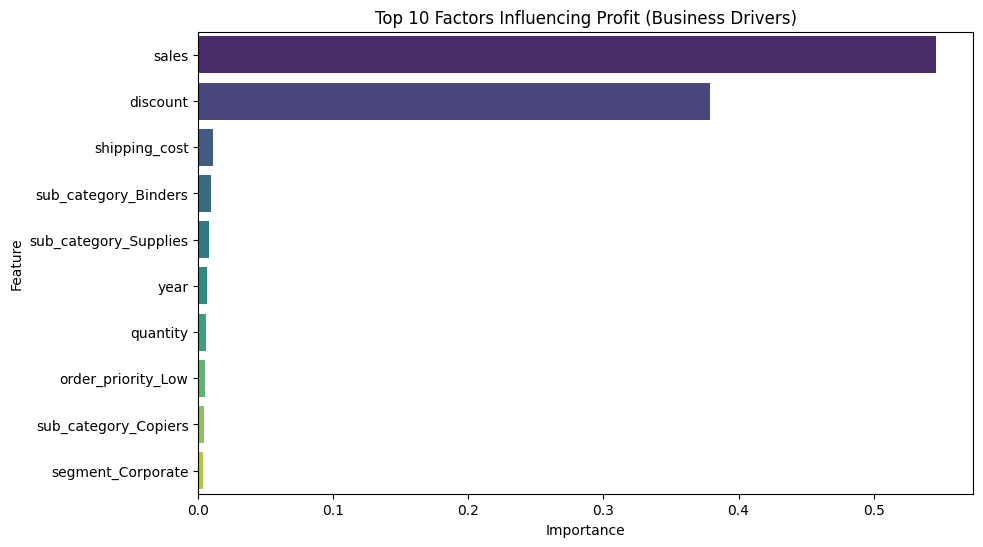

In [95]:
# 1. ดึงโมเดลที่ดีที่สุดจาก Optuna Study (สมมติว่าคุณเก็บไว้ในชื่อ final_pipeline)
best_model = final_pipeline.named_steps['regressor']
preprocessor = final_pipeline.named_steps['preprocessor']

# 2. ดึงชื่อฟีเจอร์หลังจากทำ OneHot Encoding
cat_features = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(cat_cols)
all_features = num_cols + list(cat_features)

# 3. สร้าง DataFrame สำหรับ Feature Importance
importances = pd.DataFrame({
    'Feature': all_features,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 4. พล็อตกราฟ 10 อันดับแรก
plt.figure(figsize=(10, 6))
sns.barplot(data=importances.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Factors Influencing Profit (Business Drivers)')
plt.show()

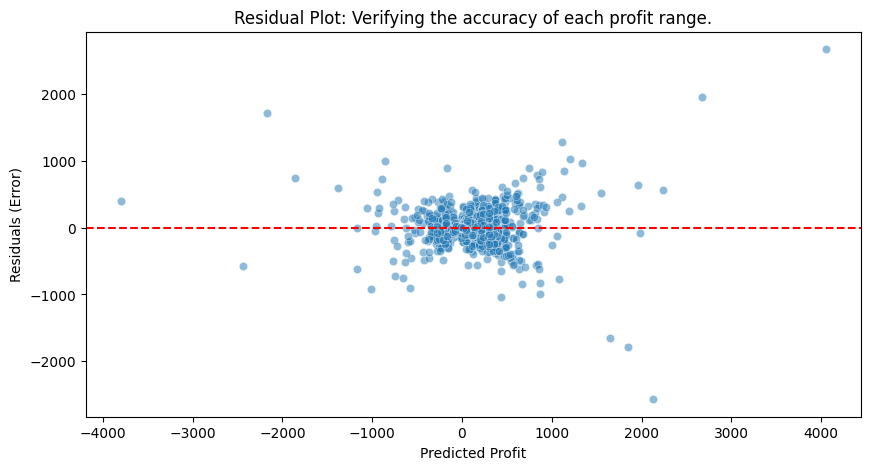

In [107]:
residuals = y_test - y_pred
plt.figure(figsize=(10, 5))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Profit')
plt.ylabel('Residuals (Error)')
plt.title('Residual Plot: Verifying the accuracy of each profit range.')
plt.show()

In [110]:
import joblib

# เซฟโมเดลและตัวแปรที่จำเป็น
model_data = {
    'pipeline': final_pipeline,
    'num_cols': num_cols,
    'cat_cols': cat_cols
}
joblib.dump(model_data, 'profit_prediction_model.pkl')

['profit_prediction_model.pkl']